In [56]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [57]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [58]:
import openseespy.opensees as ops

#Soil Element Properties
elasto_mat_tag = 1
thickness = 1.0
type = "PlaneStrain"

# Soil Material properties
E = 200e6         # Elastic modulus in Pa
nu = 0.3          # Poisson's ratio
rho = 0.0         # Density

# Storage for created nodes and elements
created_nodes = []
created_elements = []
block_registry = {}

def generate_block(start_x, start_y, length, height, node_offset, elem_offset, mat_tag, box_width, box_height, block_name="block"):
    num_x = int(length / box_width)
    num_y = int(height / box_height)

    def block_node_id(i, j):
        return node_offset + j * (num_x + 1) + i + 1

    block_nodes = []
    block_elements = []

    # Create nodes
    for j in range(num_y + 1):
        for i in range(num_x + 1):
            nid = block_node_id(i, j)
            x = start_x + i * box_width
            y = start_y + j * box_height
            ops.node(nid, x, y)
            created_nodes.append((nid, x, y))
            block_nodes.append(nid)

    # Create elements
    eid = elem_offset
    for j in range(num_y):
        for i in range(num_x):
            n1 = block_node_id(i, j)
            n2 = block_node_id(i + 1, j)
            n3 = block_node_id(i + 1, j + 1)
            n4 = block_node_id(i, j + 1)
            # element quadUP $eleTag $iNode $jNode $kNode $lNode $thick $matTag $bulk $fmass $hPerm $vPerm <$b1=0 $b2=0 $t=0>
            ops.element("quad", eid, n1, n2, n3, n4, thickness, type, mat_tag)
            created_elements.append((eid, n1, n2, n3, n4))
            block_elements.append(eid)
            eid += 1

    # Register block
    block_registry[block_name] = {
        "nodes": block_nodes,
        "elements": block_elements,
    }

    return (node_offset + (num_x + 1) * (num_y + 1), elem_offset + num_x * num_y)

# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2,
            1.8,
            9600.0,
            27000.0,
            36,
            0.1,
            101.0,
            0.0,
            26,
            0.067,
            0.23,
            0.06,
            0.27,
            20,
            5.0,
            3.0,
            1.0,
            0.0,
            0.77,
            0.9,
            0.02,
            0.7,
            101.0,
        )
        # element thickness
        # body force in x-direction
        # body force in y-direction
        # create wrapper material for initial state analysis
soil_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

    #elasto_mat_tag = 100
    # Define material
    #ops.nDMaterial("ElasticIsotropic", elasto_mat_tag, E, nu, rho)

    # Define contact material
contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0)

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
node_offset, elem_offset = generate_block(45, 32, 8.0, 8.0, node_offset, elem_offset, elasto_mat_tag, 0.5 , 0.5, block_name="OAE_Soil_block")

In [59]:
# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

# Inputs
start_id = 2
end_id = 16
step = 1

# Generate node list
bottom_nodes = list(range(start_id, end_id + 1, step))

# Apply fixity
for nid in bottom_nodes:
    ops.fix(nid, *fixYonly)


In [60]:
ops.fix(1, *fixXY)
ops.fix(17, *fixXY)

In [61]:
# Input ranges
primary_start = 18
primary_end   = 273
primary_step  = 17

secondary_start = 34
secondary_end   = 289
secondary_step  = 17

# DOFs to constrain
dofs = [1, 2]

# Generate node lists
primary_nodes = list(range(primary_start, primary_end + 1, primary_step))
secondary_nodes = list(range(secondary_start, secondary_end + 1, secondary_step))

# Apply equalDOF constraints
for r, c in zip(primary_nodes, secondary_nodes):
    ops.equalDOF(r, c, *dofs)


In [62]:
existing_tags = ops.getNodeTags()
start_id = max(existing_tags) + 1 if existing_tags else 1
print(start_id)

290


In [63]:
opst.vis.plotly.plot_model(show_node_numbering=True)

In [64]:
existing_tags = ops.getNodeTags()
start_id = max(existing_tags) + 1 if existing_tags else 1
print(start_id)
# Inputs
lagrange_start_id = 400
num_lagrange_nodes = 15 # same as beam qty
x_coord = 52.75
y_coord = 40.25

# Output list
lagrange_node_ids = []

# Create nodes
for i in range(num_lagrange_nodes):
    nid = lagrange_start_id + i
    ops.node(nid, x_coord, y_coord)
    created_nodes.append((nid, x_coord, y_coord))
    lagrange_node_ids.append(nid)

# Register block
block_registry["lagrange_nodes_set2"] = {
    "nodes": lagrange_node_ids,
    "elements": []
}
lagrange_node_ids_set_b = block_registry["lagrange_nodes_set2"]["nodes"]
print(lagrange_node_ids_set_b)

290
[400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414]


In [65]:
ops.model("Basic", "-ndm", 2, "-ndf", 3)

In [66]:
pad_foundation = [
[45.250 , 40.250],
[45.750 , 40.250],
[46.250 , 40.250],
[46.750 , 40.250],
[47.250 , 40.250],
[47.750 , 40.250],
[48.250 , 40.250],
[48.750 , 40.250],
[49.250 , 40.250],
[49.750 , 40.250],
[50.250 , 40.250],
[50.750 , 40.250],
[51.250 , 40.250],
[51.750 , 40.250],
[52.250 , 40.250],
[52.750 , 40.250],
]

start_id = start_id
segment_node_ids = []

for i, (x, y) in enumerate(pad_foundation):
    nid = start_id + i
    ops.node(nid, x, y)
    created_nodes.append((nid, x, y))
    segment_node_ids.append(nid)

# Register segment_lining as a separate block
block_registry["pad_foundation"] = {
    "nodes": segment_node_ids,
    "elements": []
}

In [67]:
existing_tags = ops.getNodeTags()
start_id = max(existing_tags) + 1 if existing_tags else 1
print(start_id)

415


In [68]:
pad_founda_nodes = block_registry["pad_foundation"]["nodes"]
print(pad_founda_nodes)

[290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305]


In [69]:

# Inputs
beam_nodes = pad_founda_nodes  # Example node list (ordered start → end)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3
beam_start_id = 400  # Starting element tag

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200e6, 0.5, 0.000975)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

# Create elements
beam_elem_ids = []
for i in range(len(beam_nodes) - 1):
    sN = beam_nodes[i]
    eN = beam_nodes[i + 1]
    eid = beam_start_id + i
    ops.element("dispBeamColumn", eid, sN, eN, transFTag, intTag)
    created_elements.append((eid, sN, eN))
    beam_elem_ids.append(eid)

# Register block
block_registry["pad_footing_beam"] = {
    "nodes": beam_nodes,
    "elements": beam_elem_ids
}

In [70]:
opst.vis.plotly.plot_model(show_node_numbering=True)

In [71]:
ground_slave_nodes = [274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288] # same as beam qty

In [72]:
lagrange_node_ids_set_b = block_registry["lagrange_nodes_set2"]["nodes"]
print(lagrange_node_ids_set_b)

[400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414]


In [73]:
last_eid = max(ops.getEleTags()) if ops.getEleTags() else 0
print("Last element ID:", last_eid)

Last element ID: 414


In [74]:
master_nodes = pad_founda_nodes
slave_nodes = ground_slave_nodes
lagrange_nodes = lagrange_node_ids_set_b

contact_elem_ids = []
beam_start_id = 3050
for i in range(len(slave_nodes)):
    tag = beam_start_id + i
    iN = master_nodes[i]
    jN = master_nodes[i + 1]
    sN = slave_nodes[i]
    IN = lagrange_nodes[i]

    ops.element("BeamContact2D", tag, iN, jN, sN, IN, contact_mat, 0.5, 1e-10, 1e-10)
    created_elements.append((tag, iN, jN, sN, IN))
    contact_elem_ids.append(tag)

block_registry["contact_beams_right"] = {
    "nodes": master_nodes + slave_nodes + lagrange_nodes,
    "elements": contact_elem_ids
}

In [75]:
ops.fix(290, 0, 1, 0)
ops.fix(305, 0, 1, 0)

In [76]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [77]:
OPSVIS = opst.vis.pyvista

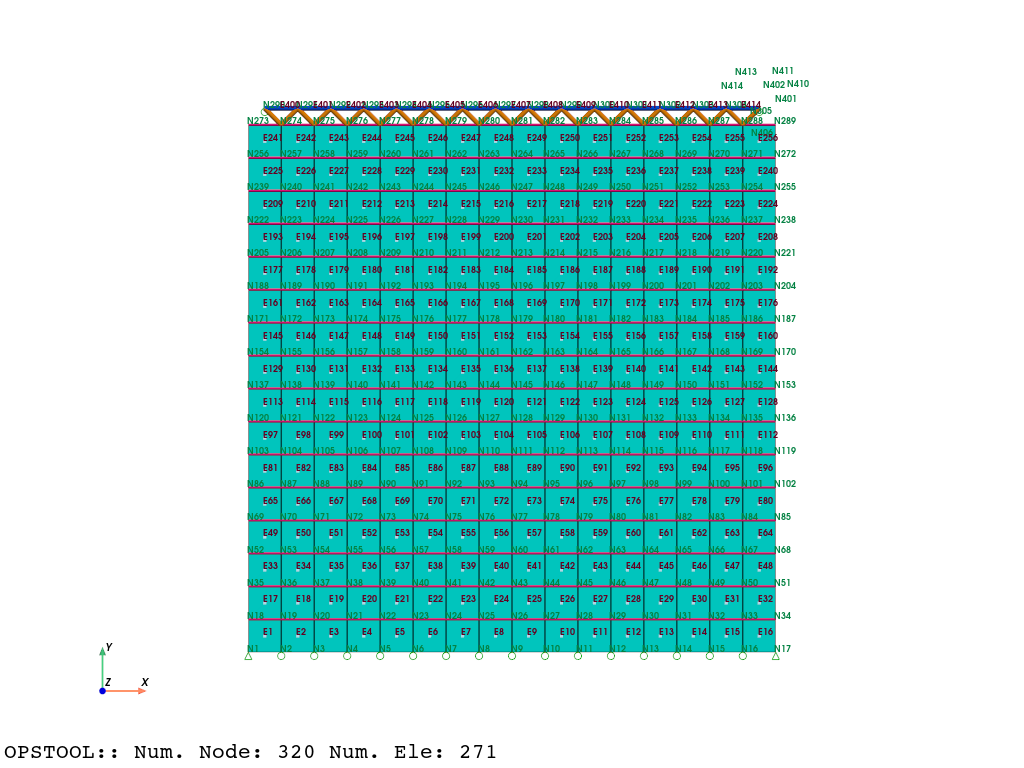

In [78]:
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [79]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [80]:
# define analysis parameters for gravity phase
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [81]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
ops.setParameter("-val", 0, "-eleRange", 3050, 3064, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON


In [82]:
# update soil material to consider elastoplastic behavior and analyze a few more steps
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
ops.setParameter("-val", 1, "-eleRange", 3050, 3064, "friction")

InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [83]:
# define analysis parameters for excavation phase
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 60)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [84]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [85]:
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
ops.load(298, 0, -5, 0)

In [86]:
ops.analyze(1)

0

In [87]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

Lift 1 removed


In [88]:
ops.load(292, 0, -20, 0)

In [89]:
ops.analyze(1)

0

In [90]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 2 removed")

Lift 2 removed


In [91]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [92]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [93]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [94]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

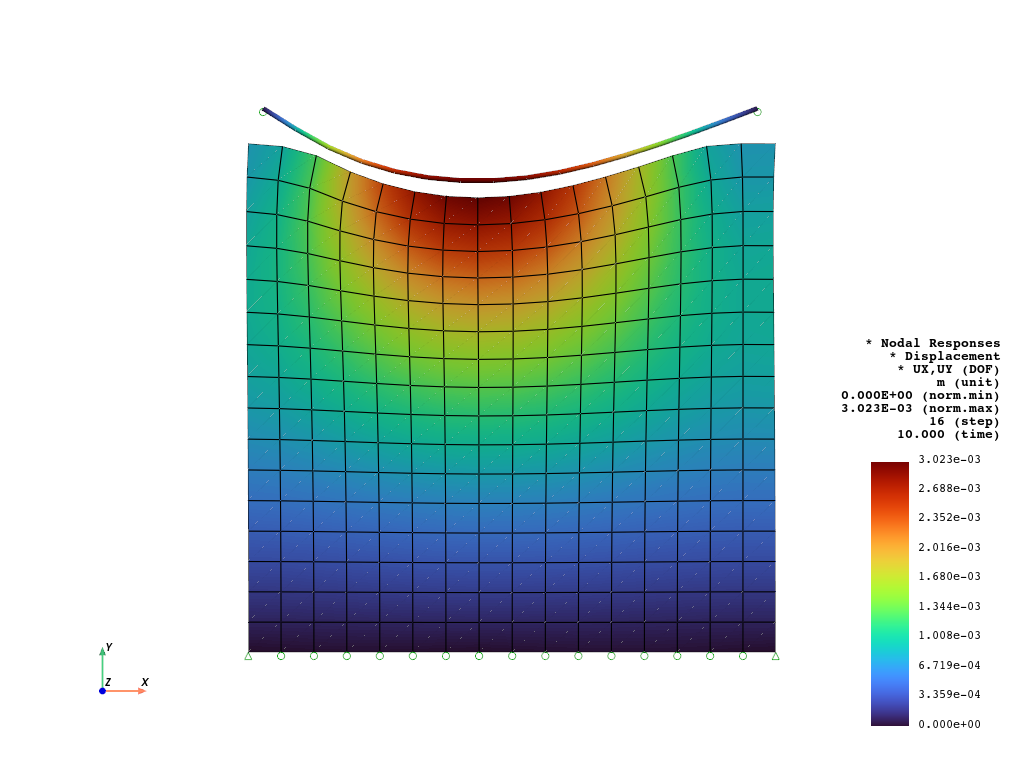

In [95]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

In [96]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=2,
    scale=2,
    savefig="NodalRespAnimationA.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved to NodalRespAnimationA.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

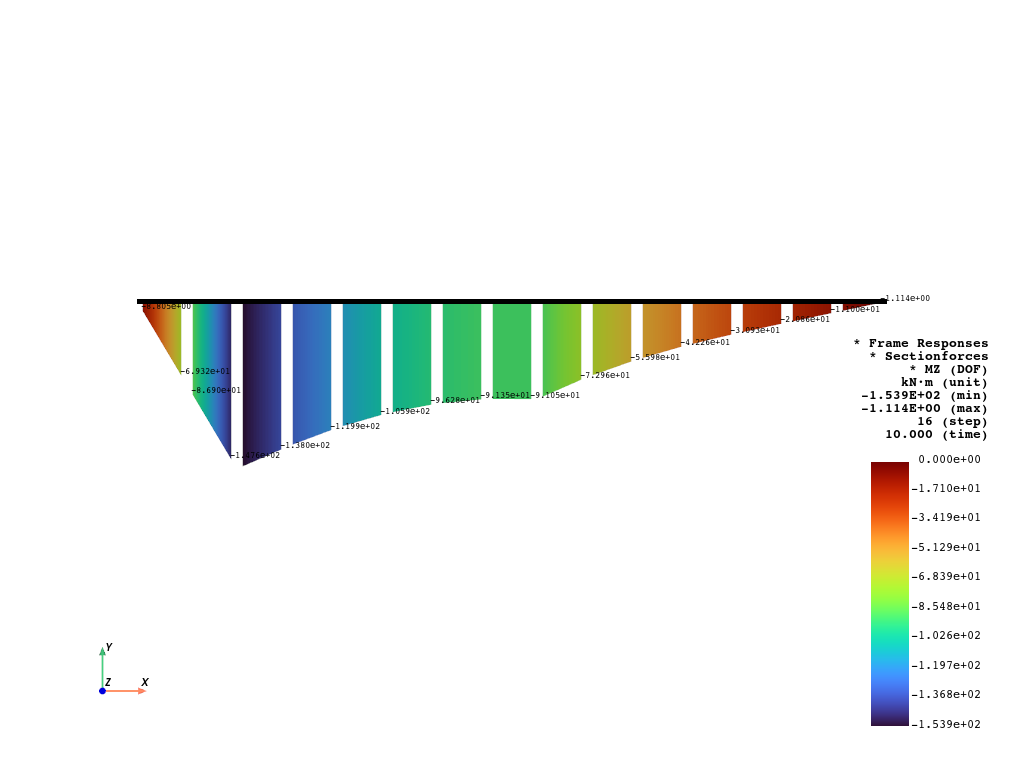

In [97]:
plotter = opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="jupyterlab")

In [98]:
opsvis.plot_frame_responses_animation(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    framerate=2,
    scale=3,
    line_width=4,
    savefig="FrameForcesMZ_A.gif",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved as FrameForcesMZ_A.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

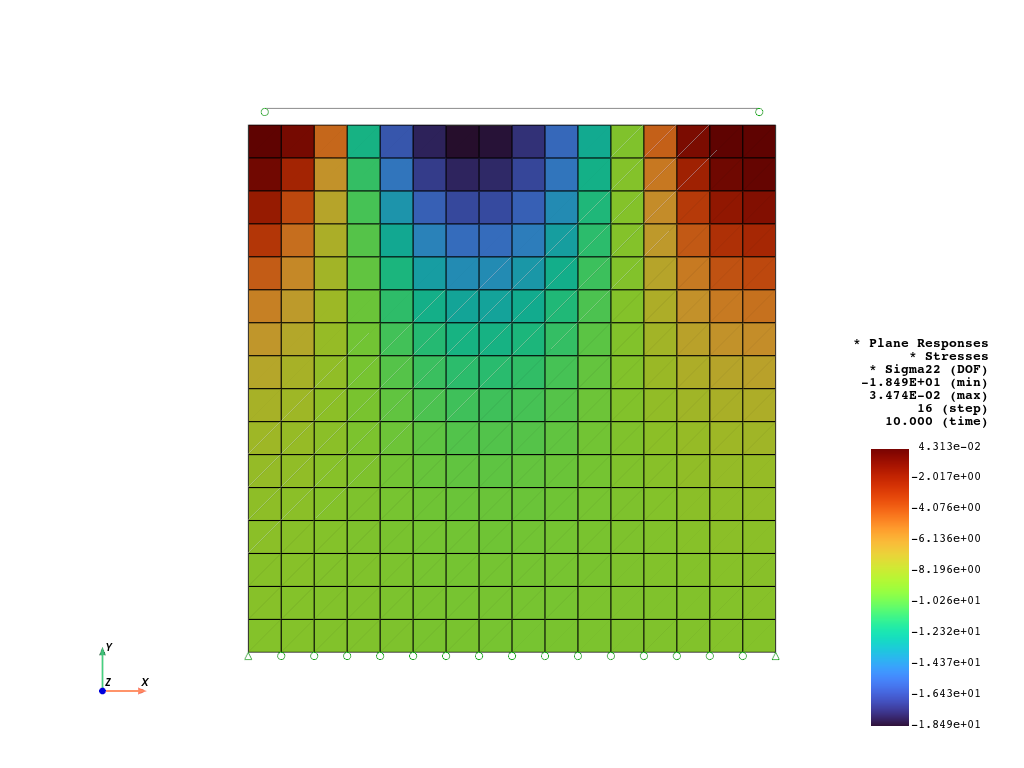

In [99]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22"
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

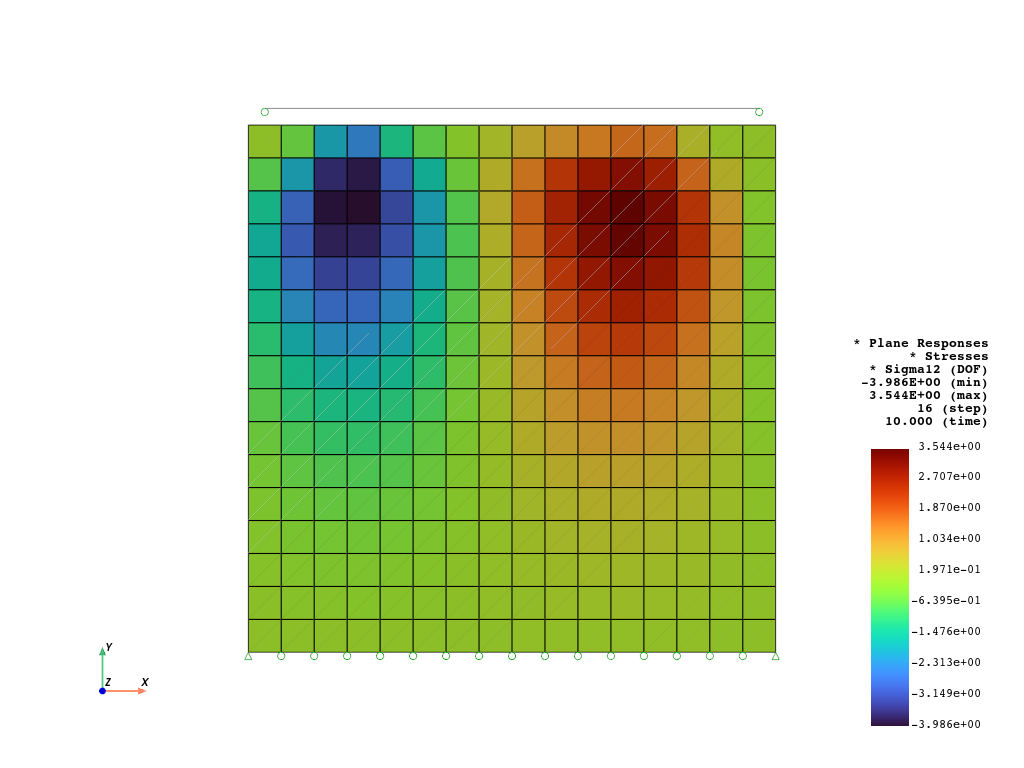

In [100]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma12"
).show(jupyter_backend="jupyterlab")

In [101]:
data = opst.post.get_element_responses(odb_tag=1, ele_type="Contact")

OPSTOOL ::  Loading Contact response data from .opstool.output/RespStepData-1.nc ...

In [102]:
print(data)

<xarray.Dataset> Size: 11kB
Dimensions:       (time: 17, eleTags: 15, globalDOFs: 3, localDOFs: 3,
                   slipDOFs: 2)
Coordinates:
  * eleTags       (eleTags) int64 120B 3050 3051 3052 3053 ... 3062 3063 3064
  * globalDOFs    (globalDOFs) <U2 24B 'Px' 'Py' 'Pz'
  * localDOFs     (localDOFs) <U2 24B 'N' 'Tx' 'Ty'
  * slipDOFs      (slipDOFs) <U2 16B 'Tx' 'Ty'
  * time          (time) float32 68B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0
Data variables:
    globalForces  (time, eleTags, globalDOFs) float32 3kB -0.0 -0.0 ... -0.0 0.0
    localForces   (time, eleTags, localDOFs) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0
    localDisp     (time, eleTags, localDOFs) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0
    slips         (time, eleTags, slipDOFs) float32 2kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    Px:       Global force in the x-direction on the constrained node
    Py:       Global force in the y-direction on the constrained node
    Pz:       Global force in the z-direction on the con

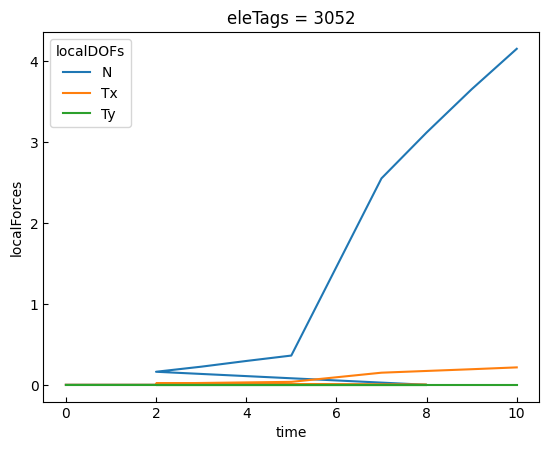

In [103]:
data["localForces"].sel(eleTags=3052).plot.line(x="time")
plt.show()

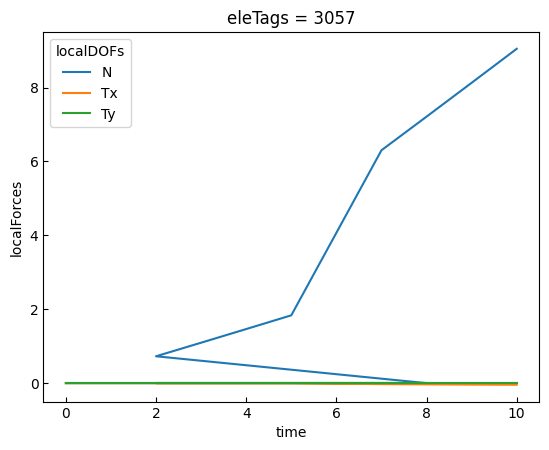

In [104]:
data["localForces"].sel(eleTags=3057).plot.line(x="time")
plt.show()

In [105]:
data["localForces"].sel(eleTags=3057).data

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 7.2723317e-01,  8.8368164e-04,  0.0000000e+00],
       [ 1.0944721e+00,  1.3355352e-03,  0.0000000e+00],
       [ 1.4638366e+00,  1.7616540e-03,  0.0000000e+00],
       [ 1.8354239e+00,  2.2243743e-03,  0.0000000e+00],
       [ 6.3021312e+00, -2.6574787e-02,  0.0000000e+00],
       [ 7.2117262e+00, -3.3400644e-02,  0.0000000e+00],
       [ 8.1276951e+00, -3.9755881e-02,  0.0000000e+00],
       [ 9.0476866e+00, -4.4229850e-02,  0.0000000e+00]], dtype=float32)

In [106]:
data["localDisp"].sel(eleTags=3057).data

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

In [107]:
data_frame = opst.post.get_element_responses(odb_tag=1, ele_type="Frame")

OPSTOOL ::  Loading Frame response data from .opstool.output/RespStepData-1.nc ...

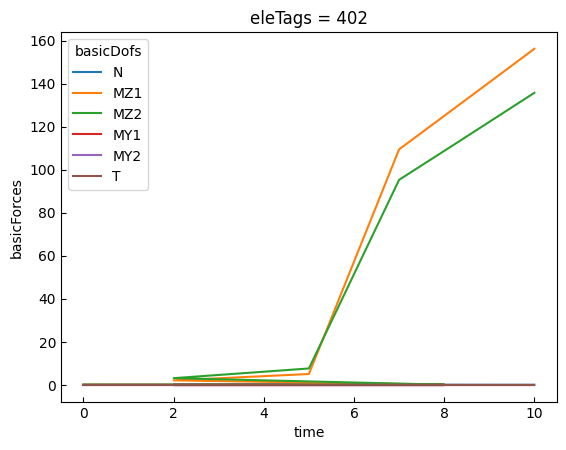

In [108]:
data_frame["basicForces"].sel(eleTags=402).plot.line(x="time")
plt.show()

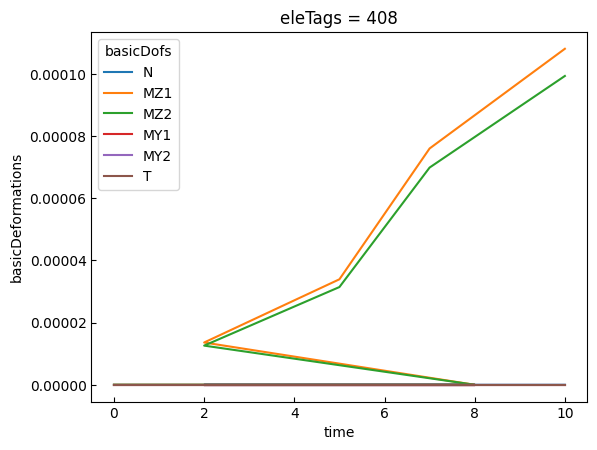

In [109]:
data_frame["basicDeformations"].sel(eleTags=408).plot.line(x="time")
plt.show()